## Preprocesamiento de texto


Para controlar la visualizacion usar:
* https://www.color-blindness.com/coblis-color-blindness-simulator/
* https://colorbrewer2.org/#type=diverging&scheme=BrBG&n=3

In [1]:
# Cargar las librerías necesarias
from dotenv import load_dotenv
import pandas as pd
import pickle 
import os
import sys
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
load_dotenv() 

True

In [2]:
HEALTH_CYAN = "#0077A8"   # celeste medio
GRAY_MAIN   = "#8F8F8F"
GRAY_LIGHT  = "#E0E0E0"
GRAY_DARK   = "#3A3A3A"

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import locale

locale.setlocale(locale.LC_ALL, 'es_AR.UTF-8')
#'es_ES.UTF-8'
#'es_ES'
#'spanish'

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette=[HEALTH_CYAN, GRAY_MAIN, GRAY_LIGHT, GRAY_DARK]
)

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.titlesize": 14,
    "font.size": 18,
    "axes.titleweight": "bold",
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.edgecolor": "#2B2B2B",
    "axes.labelcolor": "#2B2B2B",
    "text.color": "#2B2B2B",
    "grid.color": "#E5E5E5",
    "grid.linestyle": "--",
    "grid.alpha": 0.7,
    "legend.fontsize": 14,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white"
})


### Lectura de datos


In [4]:
# Configurar path
load_dotenv() # Cargar las variables de entorno del archivo .env
BASE_DIR =  os.getenv("DIR_BASE")
RESULTADOS_DIR = os.getenv("DIR_DATOS_PROCESADOS") # Acceder a las variables de entorno
sys.path.append(BASE_DIR)
sys.path.append(RESULTADOS_DIR)

pd.set_option('display.max_colwidth', None)

In [5]:
# Abrir
with open(RESULTADOS_DIR + 'base_texto_df_ley_0924.pkl', 'rb') as file: 
    base_texto_df = pickle.load(file)
base_texto_df.head()

,Proyecto.ID,Título,Título procesado,Título normalizado,Cant_token,Cant_token_procesados,Cant_token_normalizado,Proyecto_SALUD,Resultado,Periodo,Año,Tokens
0,HCDN272750,"REGIMEN LEGAL DE LOS DECRETOS DE NECESIDAD Y URGENCIA, DE DELEGACION LEGISLATIVA Y DE PROMULGACION PARCIAL DE LEYES - LEY 26122 -. MODIFICACIONES, SOBRE FUNCIONAMIENTO DE LA COMISION BICAMERAL PERMANENTE.",regimen legal de los decretos de necesidad y urgencia de delegacion legislativa y de promulgacion parcial de leyes ley numero modificaciones sobre funcionamiento de la comision bicameral permanente,regimen legal decreto necesidad urgencia delegacion legislativo promulgacion parcial ley funcionamiento comision bicameral permanente,30,28,14,0.0,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN,141.0,2024,"[regimen, legal, decreto, necesidad, urgencia, delegacion, legislativo, promulgacion, parcial, ley, funcionamiento, comision, bicameral, permanente]"
1,HCDN272749,DECLARASE LA PROHIBICION DE DESPIDOS Y SUSPENSIONES DE TRABAJADORES DE LA AGENCIA NACIONAL DE DISCAPACIDAD - ANDIS - POR EL TERMINO DE DOS AÑOS.,declarase la prohibicion de despidos y suspensiones de trabajadores de la agencia nacional de discapacidad andis por el termino de dos anos,declarar prohibicion despido suspension trabajador agencia nacional discapacidad andis termino ano,24,22,11,0.0,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN,141.0,2024,"[declarar, prohibicion, despido, suspension, trabajador, agencia, nacional, discapacidad, andis, termino, ano]"
2,HCDN272728,SISTEMA INTEGRADO DE JUBILACIONES Y PENSIONES - LEY 24241 -. MODIFICACION ESTABLECIENDO UN NUEVO INDICE DE MOVILIDAD DE LAS PRESTACIONES.,sistema integrado de jubilaciones y pensiones ley numero modificacion estableciendo un nuevo indice de movilidad de las prestaciones,sistema integrado jubilacion pension establecer indice movilidad prestacion,20,18,8,0.0,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN,141.0,2024,"[sistema, integrado, jubilacion, pension, establecer, indice, movilidad, prestacion]"
3,HCDN272729,ASIGNACIONES MENSUALES VITALICIAS - LEY 24018 -. MODIFICACIONES SOBRE JUBILACIONES Y PENSIONES DE PRIVILEGIO.,asignaciones mensuales vitalicias ley numero modificaciones sobre jubilaciones y pensiones de privilegio,asignacion mensual vitalicio jubilacion pension privilegio,14,12,6,0.0,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN,141.0,2024,"[asignacion, mensual, vitalicio, jubilacion, pension, privilegio]"
4,HCDN272717,"COMPLEMENTARIA PERMANENTE DE PRESUPUESTO - LEY 11672 -. MODIFICACION DEL ARTICULO 87, SOBRE REASIGNACION DE DISPONIBILIDADES PRESUPUESTARIAS, EXCEDENTES Y/O REMANENTES DE LOS FONDOS FIDUCIARIOS. CREACION DE LA COMISION PARA EL RELEVAMIENTO, LA AUDITORIA Y EL ORDENAMIENTO NORMATIVO Y OPERATIVO DE LOS FONDOS FIDUCIARIOS PUBLICOS EN EL AMBITO DE LA H. CAMARA.",complementaria permanente de presupuesto ley numero modificacion del articulo numero sobre reasignacion de disponibilidades presupuestarias excedentes y o remanentes de los fondos fiduciarios creacion de la comision para el relevamiento la auditoria y el ordenamiento normativo y operativo de los fondos fiduciarios publicos en el ambito de la h camara,complementario permanente presupuesto reasignacion disponibilidad presupuestaria excedente remanente fondo fiduciario creacion comision relevamiento auditoria ordenamiento normativo operativo fondo fiduciario publico ambito camara,51,50,22,0.0,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN,141.0,2024,"[complementario, permanente, presupuesto, reasignacion, disponibilidad, presupuestaria, excedente, remanente, fondo, fiduciario, creacion, comision, relevamiento, auditoria, ordenamiento, normativo, operativo, fondo, fiduciario, publico, ambito, camara]"


In [6]:
base_texto_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33097 entries, 0 to 33096
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   Proyecto.ID             33097 non-null  category
 1   Título                  33097 non-null  category
 2   Título procesado        33097 non-null  object  
 3   Título normalizado      33097 non-null  object  
 4   Cant_token              33097 non-null  int64   
 5   Cant_token_procesados   33097 non-null  int64   
 6   Cant_token_normalizado  33097 non-null  int64   
 7   Proyecto_SALUD          33097 non-null  float64 
 8   Resultado               33097 non-null  category
 9   Periodo                 33097 non-null  float64 
 10  Año                     33097 non-null  int32   
 11  Tokens                  33097 non-null  object  
dtypes: category(3), float64(2), int32(1), int64(3), object(3)
memory usage: 3.9+ MB


In [7]:
# Chequeamos si textos vacios en salud
base_texto_df[ (base_texto_df['Proyecto_SALUD']==1) & (base_texto_df['Cant_token_normalizado']<1)]

,Proyecto.ID,Título,Título procesado,Título normalizado,Cant_token,Cant_token_procesados,Cant_token_normalizado,Proyecto_SALUD,Resultado,Periodo,Año,Tokens


Los títulos de los proyectos de ley constituyen la unidad textual principal para este trabajo, dado que se encuentran sistematizados y disponibles masivamente en formatos estructurados (CSV) a través del Portal de Datos Abiertos. A diferencia de los textos completos de los proyetos,
disponibles mayormente en formato PDF, los títulos permiten un procesamiento computacional directo sin requerir técnicas de extracción adicionales.
Por su naturaleza, los títulos son frases concisas y descriptivas que condensan el propósito central de cada iniciativa legislativa. Su brevedad, junto con su vocabulario técnico-jurídico y sanitario, los convierte en unidades informativas idóneas para un primer análisis del lenguaje legislativo especializado.


#### Figura 3.6

In [31]:
RED_HEALTH   = "#7A2E2E"
GREEN_HEALTH = "#8FBFA8"


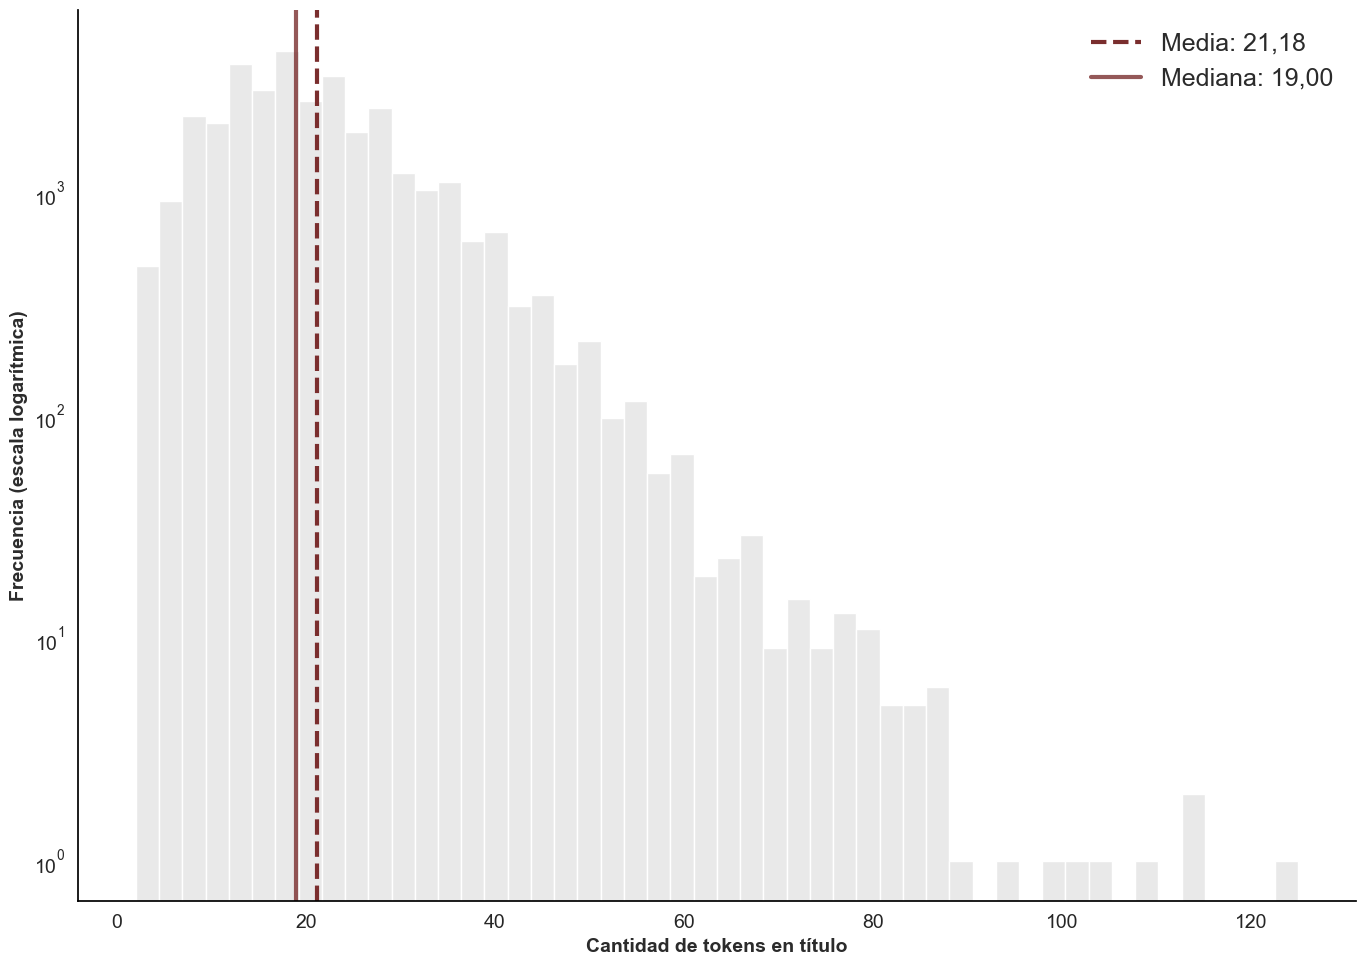

In [40]:
plt.figure(figsize=(14, 10))

# Histograma (gris claro)
ax = sns.histplot(
    data=base_texto_df,
    x="Cant_token",
    bins=50,
    color= GRAY_LIGHT,#"#BFBFBF",   
    alpha=0.7,
    kde=False
)

# Media y mediana
media = base_texto_df["Cant_token"].mean()
mediana = base_texto_df["Cant_token"].median()

# Líneas rojas
plt.axvline(
    media,
    linestyle="--",
    linewidth=3,
    color=RED_HEALTH,      # 
    label= f"Media: {locale.format_string('%.2f', media)}"  
    
)

plt.axvline(
    mediana,
    linestyle="-",
    linewidth=3,
    color=RED_HEALTH,      #
    alpha=0.8,
    label=  f"Mediana: {locale.format_string('%.2f', mediana)}"  
)

# Escala logarítmica en Y para visualizar la cola larga
plt.yscale("log")
legend = plt.legend(
    fontsize=18,      # tamaño del texto
    frameon=False     # quita el borde
)
# Quitar completamente el borde y fondo
frame = legend.get_frame()
frame.set_linewidth(0)
frame.set_edgecolor("none")
frame.set_facecolor("none")

ax.grid(False)

# Ocultar bordes superior y derecho
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Mantener solo los ejes izquierdo e inferior en negro
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')


ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x', labelsize=14)
ax.set_facecolor('white')

plt.xlabel("Cantidad de tokens en título", fontsize=14, fontweight='bold')
plt.ylabel("Frecuencia (escala logarítmica)", fontsize=14, fontweight='bold')
#plt.title(
#    "Distribución asimétrica de la cantidad de tokens en títulos de proyectos de ley",
#    fontsize=14, fontweight='bold', pad=20
#)

plt.grid(False)
plt.tight_layout()

# Guardar en alta calidad
plt.savefig(
    BASE_DIR+'imagenes/hist_tokens_asimetria.png',
    dpi=300, bbox_inches='tight',
    facecolor='white', edgecolor='none'
)
plt.show()

#### Figura 3.7

Dado que la variable correspondiente a la cantidad de token en título (Cant_token) presenta una distribución asimétrica positiva y la presencia de valores extremos (véase la Figura 3.6) se
empleó la prueba no paramétrica de Mann–Whitney U para contrastar las diferencias entre los proyectos de ley del dominio de la salud y el resto de los proyectos. Los resultados muestran
que, sin procesamiento previo, la diferencia en la longitud de los títulos entre ambos grupos es estadísticamente significativa (U = 37951547, 5, p < 0,001)

Test adecuado: Mann–Whitney U

Porque:

* Los grupos son independientes

* La distribución es asimétrica

* Probablemente no se cumple normalidad

Estás comparando una variable continua (cantidad de tokens) entre dos grupos

* Hipótesis

    * H₀: La distribución (o mediana) de tokens es igual en proyectos de salud y otros proyectos

    * H₁: Las distribuciones son diferentes

* Importante (detalle metodológico fino)

Mann–Whitney no compara estrictamente medias, sino:

La probabilidad de que un valor de un grupo sea mayor que uno del otro

O diferencias en distribución/posición

Si las formas de las distribuciones son similares, puede interpretarse como diferencia de medianas.

VER: https://www.kaggle.com/discussions/general/419726

In [12]:
from scipy.stats import mannwhitneyu

# Separar grupos
salud = base_texto_df[base_texto_df["Proyecto_SALUD"] == 1]["Cant_token"]
otros = base_texto_df[base_texto_df["Proyecto_SALUD"] == 0]["Cant_token"]

# Test Mann-Whitney
U, p_valor = mannwhitneyu(salud, otros, alternative="two-sided")

print(f"Mann-Whitney U: U={U:.1f}, p={p_valor:.4g}")

Mann-Whitney U: U=37951547.5, p=7.348e-26


C:\Users\Usuario\AppData\Local\Temp\ipykernel_22752\3653455202.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax= sns.boxplot(


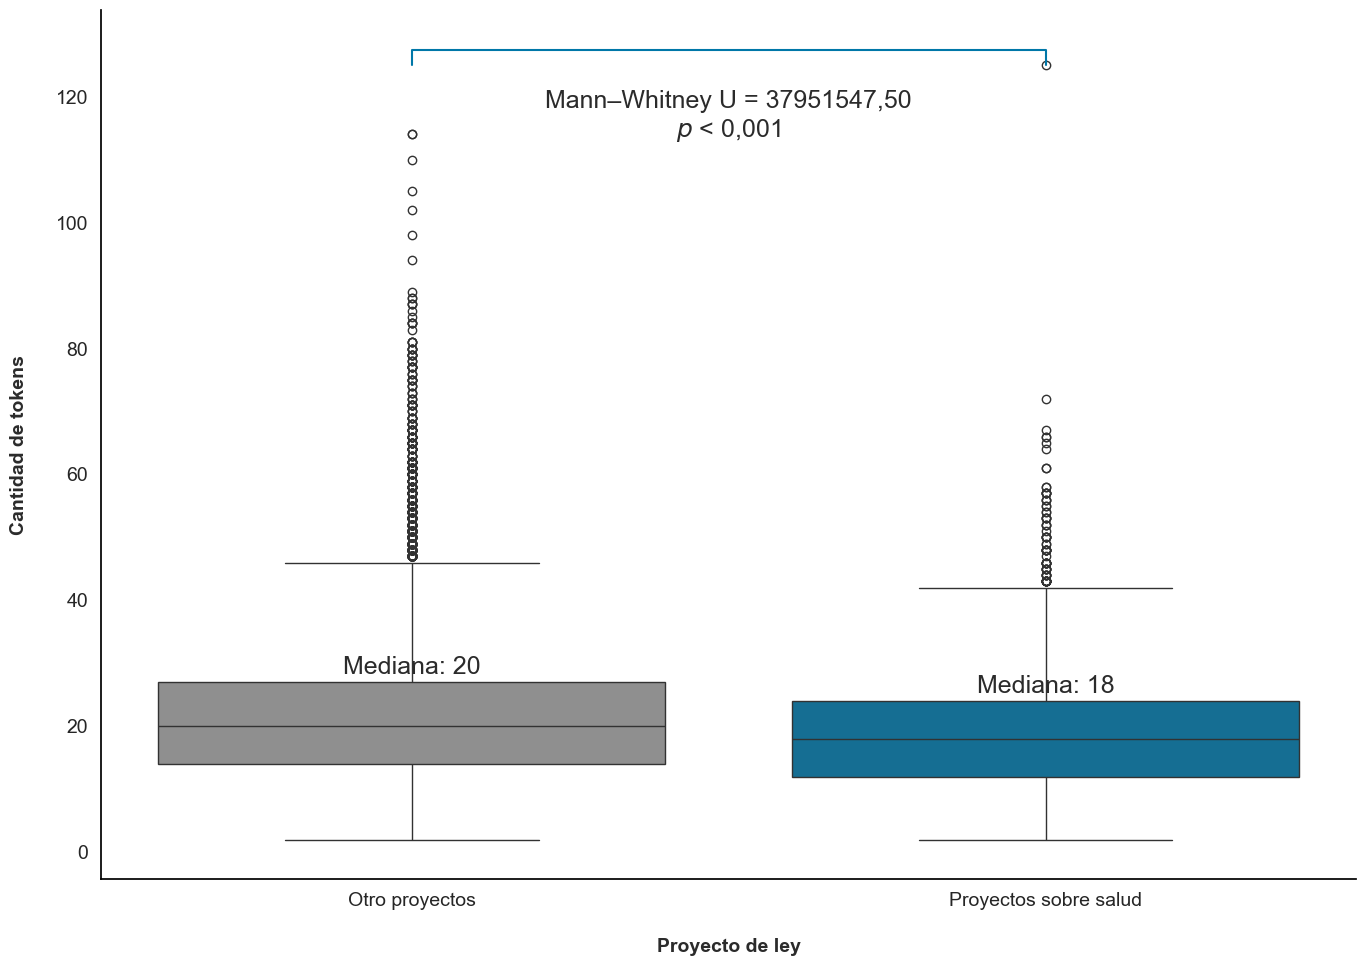

In [41]:

# Boxplot comparativo
plt.figure(figsize=(14,10))
ax= sns.boxplot(
    x="Proyecto_SALUD",
    y="Cant_token",
    data=base_texto_df,
    palette=[GRAY_MAIN, HEALTH_CYAN]

)

# Calcular mediana y Q3 por grupo
stats = base_texto_df.groupby("Proyecto_SALUD")["Cant_token"].agg(
    mediana="median",
    q3=lambda x: x.quantile(0.75)
)

# Agregar texto por encima del box (encima de Q3)
for i, row in enumerate(stats.itertuples()):
    ax.text(
        i,
        row.q3 + 0.5,   # pequeño desplazamiento vertical
        f"Mediana: {locale.format_string('%d', int(row.mediana), grouping=True)}",
        ha='center',
        va='bottom',

    )


plt.xticks([0,1], ["Otro proyectos", "Proyectos sobre salud"])
#plt.title(
#    "Distribución de cantidad de tokens en títulos de proyectos de ley\n(Test de Mann–Whitney)",
#    pad=20, fontsize=14, fontweight="bold"
#)

plt.ylabel("Cantidad de tokens", fontsize=14, fontweight='bold', labelpad=20)
plt.xlabel("Proyecto de ley", fontsize=14, fontweight='bold', labelpad=20)

# --- ANOTACIÓN DEL TEST EN LA GRÁFICA ---
y_max = base_texto_df["Cant_token"].max()

plt.text(
    0.5, y_max * 0.90,
    f"Mann–Whitney U = {locale.format_string('%.2f', U)}\n$p$ < 0,001",
    ha="center",
    va="bottom",
    fontsize=18,

)
 
# Línea de comparación (bracket)
plt.plot([0, 0, 1, 1],
         [y_max, y_max*1.02, y_max*1.02, y_max],
         linewidth=1.5)

ax.grid(False)

# Ocultar bordes superior y derecho
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Mantener solo los ejes izquierdo e inferior en negro
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x', labelsize=14)

plt.tight_layout()

# Guardar en alta calidad
plt.savefig(
    BASE_DIR+'imagenes/boxplot_saludvsOtros_mannwhitney.png', 
    dpi=300, bbox_inches='tight', 
    facecolor='white', edgecolor='none'
)

plt.show()